# 14-bcr-influenza-clonotype-clustering

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import tarfile
import re
import warnings
import matplotlib.cm as mpl_cm
import matplotlib.pyplot as plt
from cycler import cycler
from data.cell_type import annotate_cells
warnings.filterwarnings('ignore')

DATA = Path("data")


/opt/miniforge3/envs/pytcr/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
/opt/miniforge3/envs/pytcr/lib/python3.12/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):
/opt/miniforge3/envs/pytcr/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
metadata = pd.read_csv(DATA / "metadata.csv", dtype={"patient": str}).set_index("patient")
metadata


,sex,age,ethnicity,race
patient,,,,
09,female,25,Not Hispanic or Latino,white
94,female,66,Not Hispanic or Latino,white


In [3]:
def extract_tar(tar_path: Path, dest: Path) -> Path:
  if not dest.exists():
    with tarfile.open(tar_path, "r:gz") as tf:
      tf.extractall(dest)
  return dest

def read_sample(path: Path) -> tuple[ad.AnnData, ad.AnnData]:
  cellranger_tar = next(path.glob("*_cellranger.tar.gz"))
  bcrvdj_tar = next(path.glob("*_BCRVDJ.tar.gz"))

  cellranger_dir = extract_tar(cellranger_tar, path / "cellranger")
  bcrvdj_dir = extract_tar(bcrvdj_tar, path / "BCRVDJ")
  contig_csv = next(bcrvdj_dir.glob("**/filtered_contig_annotations.csv"))

  adata_gex = sc.read_10x_mtx(cellranger_dir, var_names="gene_symbols", compressed=False)
  adata_gex.var_names_make_unique()

  adata_tcr = ir.io.read_10x_vdj(contig_csv)
  ir.pp.index_chains(adata_tcr)
  ir.tl.chain_qc(adata_tcr)

  return adata_gex, adata_tcr

def add_metadata(mdata: mu.MuData):
  cell_samples = mdata.obs_names.to_series().str.split("_", expand=True)[1]
  cell_patient = cell_samples.str.split("-", expand=True)[0]

  mdata.obs["sample"] = cell_samples
  mdata.obs["patient"] = cell_patient
  mdata.obs["days_after_vaccination"] = cell_samples.str.split("-", expand=True)[1].astype(int)
  mdata.obs["age"] = cell_patient.map(metadata["age"])
  mdata.obs["sex"] = cell_patient.map(metadata["sex"])
  mdata.obs["young"] = mdata.obs["age"] < 40
  mdata.push_obs()


In [4]:
adatas_gex = {}
adatas_tcr = {}

for sample_dir in sorted(DATA.iterdir()):
  match = re.match(r"(\d+)-(\d+)", sample_dir.name)

  if not sample_dir.is_dir() or not match:
      continue

  sample = sample_dir.name
  gex, tcr = read_sample(sample_dir)

  adatas_gex[sample] = gex
  adatas_tcr[sample] = tcr

adata_gex = ad.concat(adatas_gex, index_unique="_")
adata_tcr = ad.concat(adatas_tcr, index_unique="_")

mdata = mu.MuData({"gex": adata_gex, "airr": adata_tcr})
add_metadata(mdata)
mdata


MuData object with n_obs × n_vars = 55114 × 33538
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	49339 × 33538
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
      layers:	None
    airr:	46331 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [5]:
adata = mdata['gex']
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
mdata


MuData object with n_obs × n_vars = 55114 × 33538
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	49339 × 33538
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      layers:	None
    airr:	46331 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sex' as categorical


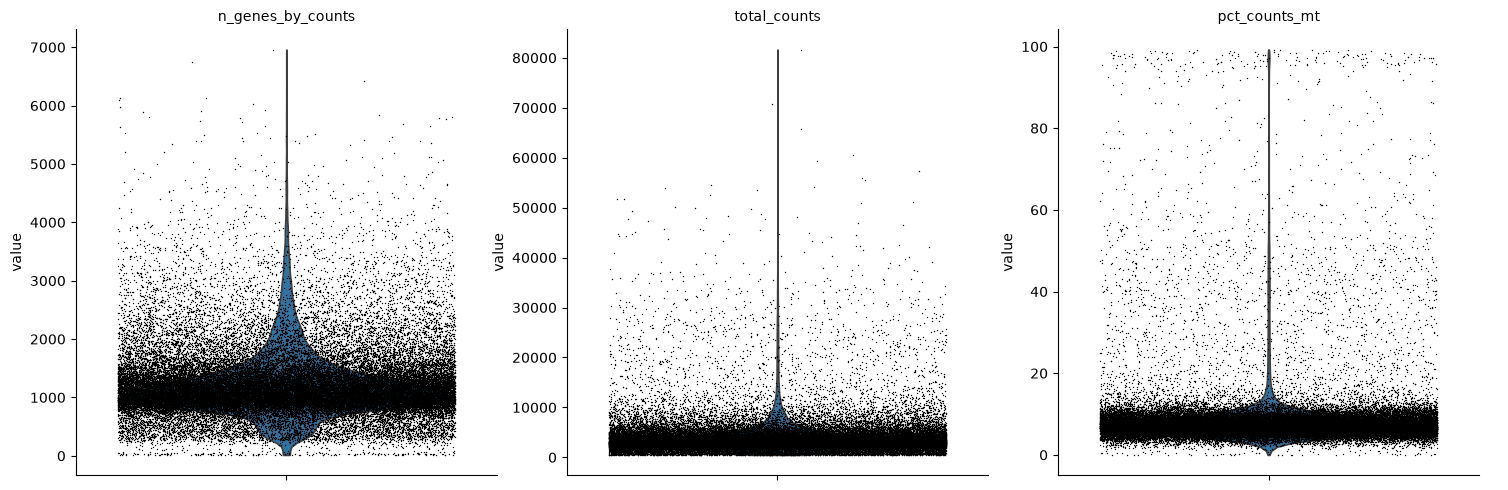

In [6]:
sc.pl.violin(
  mdata['gex'],
  ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
  jitter=0.4,
  multi_panel=True,
)


In [7]:
sc.pp.filter_cells(mdata['gex'], min_genes=200)
sc.pp.filter_genes(mdata['gex'], min_cells=3)
mu.pp.filter_obs(mdata['gex'], 'pct_counts_mt', lambda x: x < 15)
mdata.update()
mu.pp.intersect_obs(mdata)


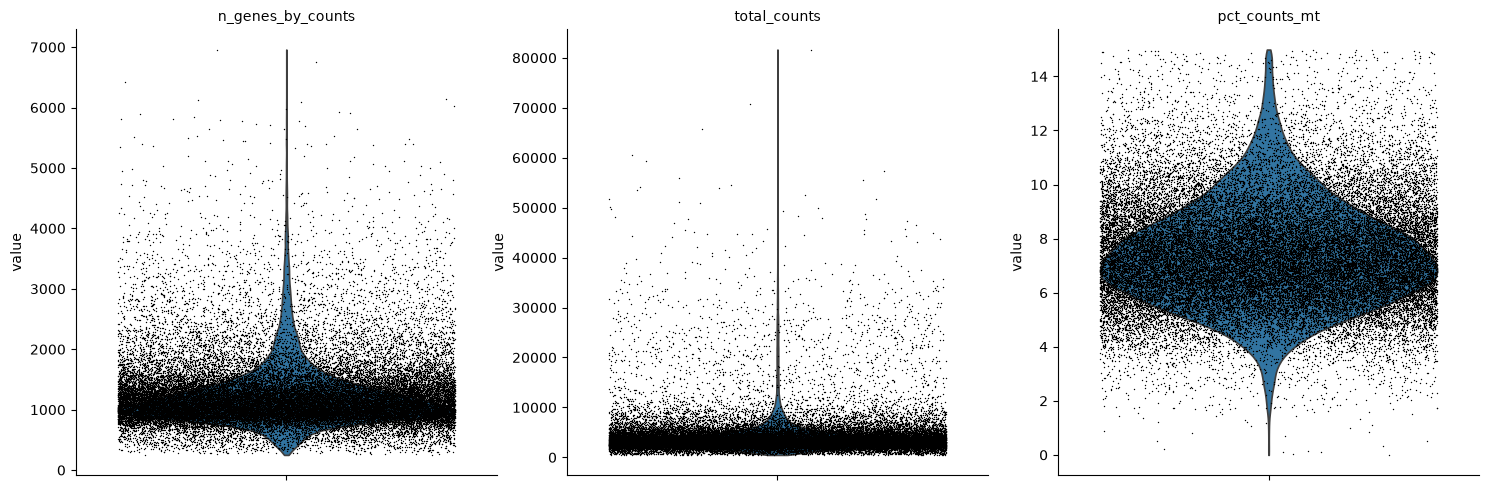

MuData object with n_obs × n_vars = 39922 × 20516
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	39922 × 20516
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      layers:	None
    airr:	39922 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [8]:
sc.pl.violin(
  mdata['gex'],
  ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
  jitter=0.4,
  multi_panel=True,
)
mdata


In [9]:
mu.pp.filter_obs(mdata, "airr:receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: x == "single pair")
mdata.update()
mu.pp.intersect_obs(mdata)
mdata


MuData object with n_obs × n_vars = 29101 × 20516
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	29101 × 20516
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      layers:	None
    airr:	29101 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [10]:
mdata['gex'].layers['counts'] = mdata['gex'].X.copy()
sc.pp.normalize_total(mdata['gex'], target_sum=1e4)
sc.pp.log1p(mdata['gex'])
sc.pp.highly_variable_genes(mdata["gex"], flavor="cell_ranger", n_top_genes=5000)
sc.tl.pca(mdata["gex"])
sc.pp.neighbors(mdata["gex"])
sc.tl.umap(mdata["gex"])


In [11]:
annotate_cells(mdata)


🔬 Input data has 29101 cells and 20516 genes
🔗 Matching reference genes in the model
🧬 5645 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


MuData object with n_obs × n_vars = 29101 × 20516
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	29101 × 20516
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'over_clustering'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    airr:	29101 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [12]:
def define_clonotypes(mdata: mu.MuData) -> mu.MuData:
  ir.pp.ir_dist(mdata)
  ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
  ir.tl.clonotype_network(mdata, min_cells=3)

  ir.pp.ir_dist(mdata, metric="tcrdist", sequence="aa", cutoff=15,)
  ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

  ir.tl.clonotype_network(mdata, min_cells=3, sequence="aa", metric="tcrdist")

  return mdata


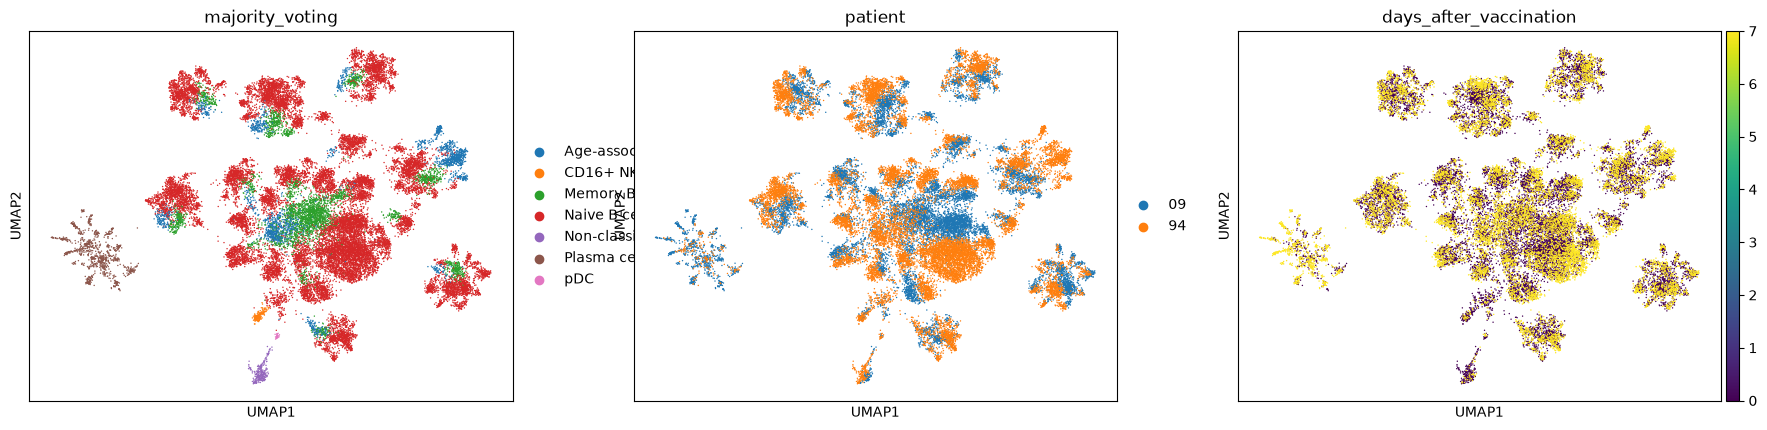

In [13]:
sc.pl.umap(
  mdata['gex'],
  color=["majority_voting", "patient", "days_after_vaccination"],
)


In [14]:
define_clonotypes(mdata)
ir.tl.clonotype_modularity(mdata, target_col="airr:cc_aa_tcrdist")


  0%|          | 0/27928 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical
... storing 'airr:patient' as categorical
... storing 'airr:sample' as categorical
... storing 'airr:sex' as categorical
... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sex' as categorical
... storing 'airr:clone_id' as categorical
... storing 'airr:cc_aa_tcrdist' as categorical


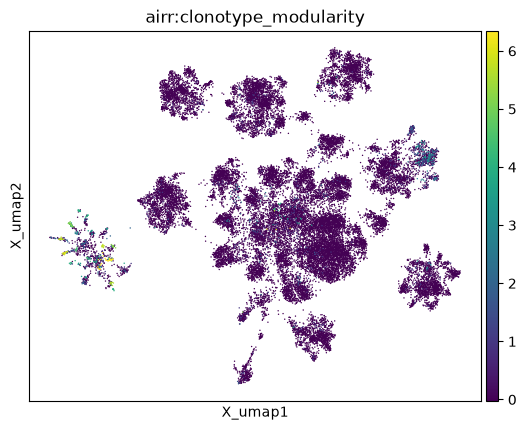

In [15]:
mu.pl.embedding(mdata, basis="gex:umap", color="airr:clonotype_modularity")


In [16]:
def mean_modularity(mdata: mu.MuData, sample: str) -> float:
  obs = mdata.obs
  obs = obs[obs['gex:sample']  == sample]
  return obs['airr:clonotype_modularity'].mean()

mean_modularity_09_7 = mean_modularity(mdata, '09-7')
mean_modularity_09_0 = mean_modularity(mdata, '09-0')
delta_mean_modularity_09 = mean_modularity_09_7 - mean_modularity_09_0

mean_modularity_94_7 = mean_modularity(mdata, '94-7')
mean_modularity_94_0 = mean_modularity(mdata, '94-0')
delta_mean_modularity_94 = mean_modularity_94_7 - mean_modularity_94_0

print(f"09-7 mean clonotype modularity: {mean_modularity(mdata, '09-7')}")
print(f"09-0 mean clonotype modularity: {mean_modularity(mdata, '09-0')}")
print(f"94-7 mean clonotype modularity: {mean_modularity(mdata, '94-7')}")
print(f"94-0 mean clonotype modularity: {mean_modularity(mdata, '94-0')}")
print(f"09 delta mean clonotype modularity: {delta_mean_modularity_09}")
print(f"94 delta mean clonotype modularity: {delta_mean_modularity_94}")


09-7 mean clonotype modularity: 0.22868042526625632
09-0 mean clonotype modularity: 0.037589170942152084
94-7 mean clonotype modularity: 0.05036511567473138
94-0 mean clonotype modularity: 0.06786968481175122
09 delta mean clonotype modularity: 0.19109125432410423
94 delta mean clonotype modularity: -0.017504569137019844


In [17]:
clonotypes_top_modularity = list(
  mdata.obs.set_index("airr:cc_aa_tcrdist")["airr:clonotype_modularity"]
  .sort_values(ascending=False)
  .index.unique()
  .values[:5]
)

clonotypes_top_modularity


['7845', '7788', '7942', '7835', '8472']

... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical
... storing 'airr:patient' as categorical
... storing 'airr:sample' as categorical
... storing 'airr:sex' as categorical
... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sex' as categorical
... storing 'airr:clone_id' as categorical
... storing 'airr:cc_aa_tcrdist' as categorical


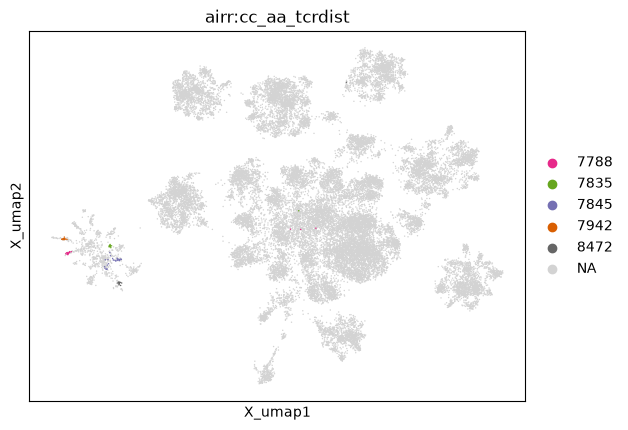

In [18]:
test_ad = mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color="airr:cc_aa_tcrdist",
  groups=clonotypes_top_modularity,
  palette=cycler(color=mpl_cm.Dark2_r.colors),
)


findfont: Failed to find font weight 300, now using 400.


<Axes: xlabel='modularity score', ylabel='-log10(FDR)'>

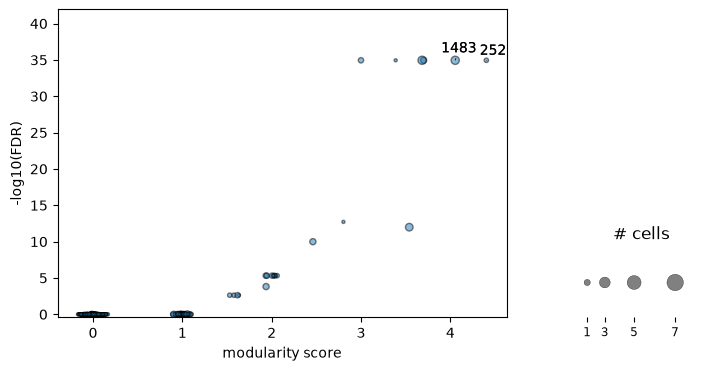

In [19]:
mdata_09_0 = mdata[mdata.obs["gex:sample"] == "09-0"].copy()
ir.pl.clonotype_modularity(mdata_09_0, base_size=20)


... storing 'cc_aa_tcrdist' as categorical


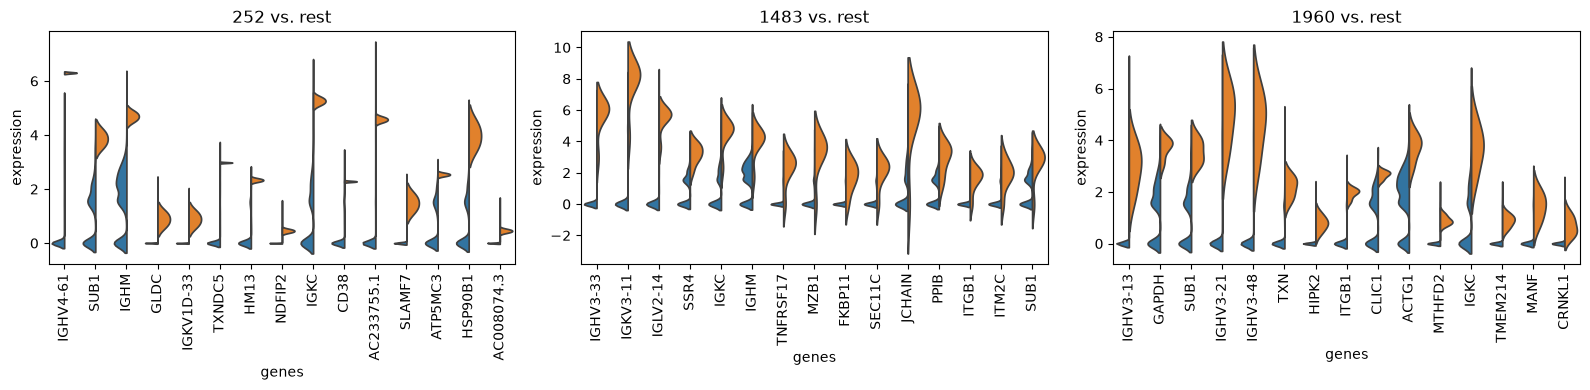

In [20]:
clonotypes_top_modularity = list(
    mdata_09_0.obs.set_index("airr:cc_aa_tcrdist")["airr:clonotype_modularity"]
    .sort_values(ascending=False)
    .index.unique()
    .values[:3]
)

with ir.get.obs_context(mdata_09_0["gex"], {"cc_aa_tcrdist": mdata_09_0.obs["airr:cc_aa_tcrdist"]}) as tmp_ad:
  sc.tl.rank_genes_groups(
    tmp_ad,
    "cc_aa_tcrdist",
    groups=clonotypes_top_modularity,
    reference="rest",
    method="wilcoxon",
  )
  fig, axes = plt.subplots(1, 3, figsize=(16, 4))
  for group, ax in zip(clonotypes_top_modularity, axes):
    sc.pl.rank_genes_groups_violin(
      tmp_ad,
      groups=[group],
      n_genes=15,
      ax=ax,
      show=False,
      strip=False,
    )
  fig.tight_layout()


In [21]:
output = {
  "mean_modularity_09_7": mean_modularity_09_7,
  "delta_mean_modularity_09": delta_mean_modularity_09,
  "best_hypothesis": 2,
  "overexpressed_genes": [
    "IGKC",
    "IGHM"
  ]
}

print(json.dumps(output, indent=2))

# with open('output.json', 'w') as f:
#     json.dump(output, f, indent=2)
# print('Results saved to output.json:')


{
  "mean_modularity_09_7": 0.22868042526625632,
  "delta_mean_modularity_09": 0.19109125432410423,
  "best_hypothesis": 2,
  "overexpressed_genes": [
    "IGKC",
    "IGHM"
  ]
}
